# Temperature dependent elastic constants

## Multiple methods to calculate elastic constants:

1. Fitting elastic energies from static calculations
2. Calculating stresses using MD calculations
3. Quasi-Harmonic approximation

# Implementation

## Overview

Assumption: Cubic cell

### 0K Elastic constants

Step 1: Get relaxed structure at 0K

Step 2: Calculate elastic constants C11, C12 and C44 at 0K

    Step 2.1: Calculate deformation gradients for a strain value (system specific)

    Step 2.2: Static calculation for relaxed and strained cell for each elastic constant
    
    Step 2.3: Get the difference in stresses on both the cells
    
    Step 2.4: Calculate the elastic constants using the below equations

Step 3: Check against fit elastic constants - fitting the energy vs strain curve

### Temperature Dependent Elastic constants

Step 1: Get relaxed structure at 0K

Step 2: Calculate elastic constants C11, C12 and C44 at specific temperature

    Step 2.1: Finite temperature equilibriation of the relaxed structure
        Step 2.1.1: Calculate lattice constant using an NPT simulation (Nose Hoover)
        Step 2.1.2: Equilibriate structure using an NVT simulation (Langevin)

    Step 2.1: Calculate deformation gradients for a strain value
    
    Step 2.2: NVT simulation (Langevin) for equilibriated and strained cell for each elastic constant
    
    Step 2.3: Get the difference in stresses on both the cells
    
    Step 2.4: Calculate the elastic constants using the below equations

Step 3: Convergence studies to calculate good range of parameters:

        ```
        input_params_scale = {
            "cell_scale_value" : [3, 5, 7, 9],
            "run" : [5000, 10000, 20000, 30000, 40000, 50000],
            "temperature" : [500],
            "strain" : [0.005],
            "seed": [1357],
            "thermostat" : ["langevin"]
        }
        ```

### Deformation gradient tensor $F$

#### $C_{11}$ deformation
Uniaxial strain $\varepsilon_{11} = \varepsilon$, all other $\varepsilon_{ij} = 0$.  
$$
F = \begin{pmatrix}
1 + \varepsilon & 0 & 0 \\
0 & 1 & 0 \\
0 & 0 & 1
\end{pmatrix}
$$

$$
C_{11} = \frac{\Delta\sigma_{11}}{\varepsilon}
$$


#### $C_{12}$ deformation
Biaxial strain $\varepsilon_{11} = \varepsilon_{22} = \varepsilon$, all other $\varepsilon_{ij} = 0$.  
$$
F = \begin{pmatrix}
1 + \varepsilon & 0 & 0 \\
0 & 1 + \varepsilon & 0 \\
0 & 0 & 1
\end{pmatrix}
$$
$$
C_{12} = \frac{\Delta\sigma_{33}}{2\varepsilon}
$$

#### $C_{44}$ deformation
Shear strain $\varepsilon_{23} = \varepsilon_{32} = \varepsilon$, all other $\varepsilon_{ij} = 0$.  
$$
F = \begin{pmatrix}
1 & 0 & 0 \\
0 & 1 & \varepsilon \\
0 & \varepsilon & 1
\end{pmatrix}
$$
$$
C_{44} = \frac{\Delta\sigma_{23}}{2\varepsilon}
$$

## Comparison with Reference

We compare our values with the paper - [M. Krief, et. al., Physical Review E, 103, 063307, 2021](https://journals.aps.org/pre/abstract/10.1103/PhysRevE.103.063307#s4)

Potential used: Copper [Mishin potential](https://www.ctcms.nist.gov/potentials/entry/2001--Mishin-Y-Mehl-M-J-Papaconstantopoulos-D-A-et-al--Cu-1/)

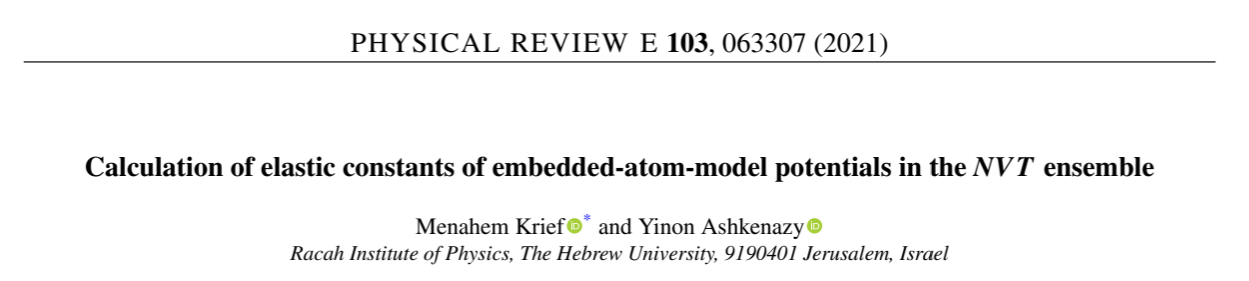

## Imports

In [1]:
from ase.build import bulk
from ase.atoms import Atoms

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from atomistics.workflows.elastic.workflow import (
    get_tasks_for_elastic_matrix,
    analyse_results_for_elastic_matrix
)

from atomistics.calculators import (
    evaluate_with_lammpslib, 
    get_potential_by_name, 
    calc_molecular_dynamics_npt_with_lammpslib, 
    calc_molecular_dynamics_nvt_with_lammpslib
)

from atomistics.calculators.lammps.libcalculator import (
    calc_static_with_lammpslib, 
    calc_molecular_dynamics_langevin_with_lammpslib
)

/cmmc/ptmp/pchilaka/Packages/atomistics/atomistics/calculators/__init__.py:63: UserWarning: calc_static_with_qe(), evaluate_with_qe() and optimize_positions_and_volume_with_qe() are not available as the import of the module named 'pwtools' failed.
  raise_warning(module_list=quantum_espresso_function, import_error=e)
/cmmc/ptmp/pchilaka/Packages/atomistics/atomistics/calculators/lammps/__init__.py:41: UserWarning: calc_molecular_dynamics_phonons_with_lammpslib() is not available as the import of the module named 'dynaphopy' failed.
  raise_warning(module_list=lammps_phonon_functions, import_error=e)
/cmmc/ptmp/pchilaka/Packages/atomistics/atomistics/calculators/__init__.py:94: UserWarning: calc_molecular_dynamics_phonons_with_lammpslib() is not available as the import of the module named 'dynaphopy' failed.
  raise_warning(module_list=lammps_phonon_functions, import_error=e)


## Create bulk sample with a guessed lattice constant

In [3]:
unit_cell = bulk('Cu', 'fcc', a=3.6514, cubic=True) # 4 atoms

In [4]:
repeated_unit_cell = unit_cell.repeat(5) # 500 atoms

In [5]:
potential_name_str = "2001--Mishin-Y--Cu-1--LAMMPS--ipr1"

potential_df = get_potential_by_name(
    potential_name=potential_name_str
)

/cmmc/ptmp/pchilaka/Packages/atomistics/atomistics/calculators/lammps/potential.py:324: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_pot["Config"] = config_lst


In [7]:
potential_df.to_dict()

{'Config': ['pair_style eam/alloy',
  'pair_coeff * * /cmmc/ptmp/pyironhb/pyiron_latest_env/share/iprpy/potential_LAMMPS/2001--Mishin-Y--Cu-1--LAMMPS--ipr1/Cu01.eam.alloy Cu'],
 'Filename': ['potential_LAMMPS/2001--Mishin-Y--Cu-1--LAMMPS--ipr1/Cu01.eam.alloy'],
 'Model': 'NISTiprpy',
 'Name': '2001--Mishin-Y--Cu-1--LAMMPS--ipr1',
 'Species': ['Cu'],
 'Citations': "[{'Mishin_2001': {'title': 'Structural stability and lattice defects in copper: Ab initio, tight-binding, and embedded-atom calculations', 'journal': 'Physical Review B', 'volume': '63', 'pages': '224106', 'number': '22', 'doi': '10.1103/physrevb.63.224106', 'publisher': 'American Physical Society (APS)', 'url': 'https://doi.org/10.1103%2Fphysrevb.63.224106', 'year': '2001', 'author': ['Y. Mishin', 'M. J. Mehl', 'D. A. Papaconstantopoulos', 'A. F. Voter', 'J. D. Kress']}}]"}

## 0K Relaxed Structure

In [ ]:
def get_relaxed_structure_at_0K(
        structure: Atoms, 
        potential: str, 
        lmp_optimizer_kwargs : dict = None
        ) -> Atoms:
    
    df_pot_selected = get_potential_by_name(
        potential_name=potential
        )
    
    result_dict = evaluate_with_lammpslib(
        task_dict={"optimize_positions_and_volume": structure},
        potential_dataframe=df_pot_selected,
        lmp_optimizer_kwargs=lmp_optimizer_kwargs
        )
    
    structure_relaxed = result_dict['structure_with_optimized_positions_and_volume']

    return structure_relaxed

In [ ]:
lmp_optimizer_kwargs={
    'min_style':'cg',
    'ionic_force_tolerance':1e-8,
    'pressure':np.zeros(6) # add anisotropy
}

In [ ]:
relaxed_unit_cell = get_relaxed_structure_at_0K(
    unit_cell, # 4 atoms
    potential_name_str, 
    lmp_optimizer_kwargs
)

relaxed_unit_cell # 4 atoms

/cmmc/ptmp/pchilaka/Packages/atomistics/atomistics/calculators/lammps/potential.py:324: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_pot["Config"] = config_lst
--------------------------------------------------------------------------

  Local host:   cmti001
  Local device: hfi1_0
--------------------------------------------------------------------------


Atoms(symbols='Cu4', pbc=True, cell=[3.6150000810785805, 3.6150000810785805, 3.6150000810785805])

## 0K Lattice Constant

In [ ]:
def get_lattice_constant_at_0K(
        structure: Atoms, 
        potential: str, 
        lmp_optimizer_kwargs : dict = None
        ) -> float:

    structure_relaxed = get_relaxed_structure_at_0K(
        structure=structure, 
        potential=potential,
        lmp_optimizer_kwargs=lmp_optimizer_kwargs
    )
    
    a_0 = structure_relaxed.get_volume()**(1/3)

    return a_0 # Angstrom

In [60]:
a_0 = get_lattice_constant_at_0K(
    structure=unit_cell, 
    potential=potential_name_str,
    lmp_optimizer_kwargs=lmp_optimizer_kwargs)

a_0 # Angstrom

/cmmc/ptmp/pchilaka/Packages/atomistics/atomistics/calculators/lammps/potential.py:324: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_pot["Config"] = config_lst


3.61500008107858

We get the same lattice constant at 0K as the reference paper!

## 0K Elastic Constants

In [13]:
def get_strain_tensor_cubic(
        structure : Atoms, 
        strain : float = 0.005
    ) -> dict:

    deformation_gradient_dict = {
        'C11': np.eye(3,3) + np.array([[ strain,      0,      0], 
                                       [      0,      0,      0],
                                       [      0,      0,      0]]),
        'C12': np.eye(3,3) + np.array([[ strain,      0,      0], 
                                       [      0, strain,      0], 
                                       [      0,      0,      0]]),
        'C44': np.eye(3,3) + np.array([[      0,      0,      0], 
                                       [      0,      0, strain], 
                                       [      0, strain,      0]])
    }

    return deformation_gradient_dict

In [14]:
def get_elastic_constants_from_stress_tensor(
        tensor_dict : dict, 
        strain : float
    ) -> list[float]:

    elastic_constants_list = []

    for constant_str, diff in tensor_dict.items():
        if constant_str == 'C11':
            constant = diff[0, 0] / strain
            elastic_constants_list.append(abs(constant))

        elif constant_str == 'C12':
            sigma33 = diff[2, 2]
            constant = (sigma33/ strain) / 2
            elastic_constants_list.append(abs(constant))

        elif constant_str == 'C44':
            sigma23 = diff[2, 1]
            constant = sigma23 / (2 * strain)
            elastic_constants_list.append(abs(constant))

    return elastic_constants_list

In [31]:
def get_stress_tensor_at_0K(
        structure : Atoms, 
        potential_dataframe : pd.DataFrame, 
        deformation_gradient : np.array
    ):
    
    structure_strained = structure.copy()
    relaxed_cell = np.array(structure_strained.get_cell().tolist())

    strained_cell = deformation_gradient@relaxed_cell
    structure_strained.set_cell(
        strained_cell, 
        scale_atoms=True
    )
    
    relaxed_dict = calc_static_with_lammpslib(
        structure=structure, 
        potential_dataframe=potential_dataframe
    )
    strained_dict = calc_static_with_lammpslib(
        structure=structure_strained,
        potential_dataframe=potential_dataframe
    )

    relaxed_dict['stress_GPa'] = relaxed_dict['stress'] / 10**4
    strained_dict['stress_GPa'] = strained_dict['stress'] / 10**4

    stress_diff = strained_dict['stress_GPa'] - relaxed_dict['stress_GPa']
    
    return stress_diff, relaxed_dict, strained_dict

In [ ]:
def calculate_elastic_constants_at_0K(
        structure : Atoms, 
        potential_name : str,
        strain : float = 0.005
    ):

    df_pot_selected = get_potential_by_name(
        potential_name=potential_name
    )

    deformation_gradient_dict = get_strain_tensor_cubic(
        structure=structure, 
        strain=strain
    )
    
    tensor_dict = {}
    for constant_str, deformation_gradient in deformation_gradient_dict.items():
        diff, relaxed_dict, strained_dict = get_stress_tensor_at_0K(
            structure=structure,
            potential_dataframe=df_pot_selected,
            deformation_gradient=deformation_gradient
        )
        
        tensor_dict[constant_str] = diff
        tensor_dict[f'relaxed_dict_{constant_str}'] = relaxed_dict
        tensor_dict[f'strained_dict_{constant_str}'] = strained_dict
    
    elastic_constants_list = get_elastic_constants_from_stress_tensor(
        tensor_dict=tensor_dict, 
        strain=strain
    )

    return elastic_constants_list, tensor_dict

In [33]:
elastic_constants_list_0, tensor_dict_0 = calculate_elastic_constants_at_0K(
    structure=relaxed_unit_cell, 
    potential_name=potential_name_str,
    strain=0.005
)

/cmmc/ptmp/pchilaka/Packages/atomistics/atomistics/calculators/lammps/potential.py:324: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_pot["Config"] = config_lst
/cmmc/ptmp/pchilaka/Packages/atomistics/atomistics/calculators/lammps/helpers.py:29: UserWarning: Warning: setting upper trangular matrix might slow down the calculation
  lmp.interactive_structure_setter(


In [36]:
elastic_constants_list_0 # GPa

print(np.round(elastic_constants_list_0, 1))

[169.2 121.4  76.3]


#### Comparing with paper

In comparison with the [reference paper](https://journals.aps.org/pre/abstract/10.1103/PhysRevE.103.063307#s4 "M. Krief, et. al., Physical Review E, 103, 063307, 2021"),

$C_{11}$=169.9GPa, $C_{12}$=122.6GPa, and $C_{44}$=76.2GPa

##### Larger super cell

In [ ]:
elastic_constants_list_0_r5, tensor_dict_0_r5 = calculate_elastic_constants_at_0K(
    structure=relaxed_unit_cell.repeat(5), # 500 atoms
    potential_name=potential_name_str,
    strain=0.005
)

/cmmc/ptmp/pchilaka/Packages/atomistics/atomistics/calculators/lammps/potential.py:324: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_pot["Config"] = config_lst
/cmmc/ptmp/pchilaka/Packages/atomistics/atomistics/calculators/lammps/helpers.py:29: UserWarning: Warning: setting upper trangular matrix might slow down the calculation
  lmp.interactive_structure_setter(


In [39]:
elastic_constants_list_0_r5 # GPa

print(np.round(elastic_constants_list_0_r5, 1))

[169.2 121.4  76.3]


In comparison with the [reference paper](https://journals.aps.org/pre/abstract/10.1103/PhysRevE.103.063307#s4 "M. Krief, et. al., Physical Review E, 103, 063307, 2021"),

$C_{11}$=169.9GPa, $C_{12}$=122.6GPa, and $C_{44}$=76.2GPa

##### Varied strain

In [40]:
elastic_constants_list_0_r5_s_0d0005, tensor_dict_0_r5_s_0d0005 = calculate_elastic_constants_at_0K(
    structure=relaxed_unit_cell.repeat(5), 
    potential_name=potential_name_str,
    strain=0.0005
)

/cmmc/ptmp/pchilaka/Packages/atomistics/atomistics/calculators/lammps/potential.py:324: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_pot["Config"] = config_lst
/cmmc/ptmp/pchilaka/Packages/atomistics/atomistics/calculators/lammps/helpers.py:29: UserWarning: Warning: setting upper trangular matrix might slow down the calculation
  lmp.interactive_structure_setter(


In [ ]:
elastic_constants_list_0_r5_s_0d0005
np.round(elastic_constants_list_0_r5_s_0d0005, 1) # GPa

array([169.8, 122.5,  76.2])

In [44]:
elastic_constants_list_0_r5_s_0d00005, tensor_dict_0_r5_s_0d00005 = calculate_elastic_constants_at_0K(
    structure=relaxed_unit_cell.repeat(5), 
    potential_name=potential_name_str,
    strain=0.00005
)

/cmmc/ptmp/pchilaka/Packages/atomistics/atomistics/calculators/lammps/potential.py:324: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_pot["Config"] = config_lst
/cmmc/ptmp/pchilaka/Packages/atomistics/atomistics/calculators/lammps/helpers.py:29: UserWarning: Warning: setting upper trangular matrix might slow down the calculation
  lmp.interactive_structure_setter(


But now, the strain is too small!

In [45]:
elastic_constants_list_0_r5_s_0d00005
np.round(elastic_constants_list_0_r5_s_0d00005, 1) #GPa

array([169.9, 122.6,   0. ])

We increase the strain by a little bit

In [46]:
elastic_constants_list_0_r5_s_0d0001, tensor_dict_0_r5_s_0d0001 = calculate_elastic_constants_at_0K(
    structure=relaxed_unit_cell.repeat(5), 
    potential_name=potential_name_str,
    strain=0.0001
)

/cmmc/ptmp/pchilaka/Packages/atomistics/atomistics/calculators/lammps/potential.py:324: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_pot["Config"] = config_lst
/cmmc/ptmp/pchilaka/Packages/atomistics/atomistics/calculators/lammps/helpers.py:29: UserWarning: Warning: setting upper trangular matrix might slow down the calculation
  lmp.interactive_structure_setter(


In [47]:
np.round(elastic_constants_list_0_r5_s_0d0001, 1) #GPa

array([169.9, 122.6,  76.2])

We get the same as the [reference paper](https://journals.aps.org/pre/abstract/10.1103/PhysRevE.103.063307#s4 "M. Krief, et. al., Physical Review E, 103, 063307, 2021"),

$C_{11}$=169.9GPa, $C_{12}$=122.6GPa, and $C_{44}$=76.2GPa

## Reference function to fit elastic constants (Jan + Yury)'s

Requires only `relaxed_unit_cell` and `potential_name_str` from previous cells

In [48]:
def fit_elastic_constants(
        structure: Atoms, 
        potential: str, 
        strains, 
        stresses=None, 
        energies=None):

    task_dict, sym_dict = get_tasks_for_elastic_matrix(
        structure=structure,
        eps_range=0.005,
        num_of_point=5,
        zero_strain_job_name="s_e_0",
        sqrt_eta=True
    )

    potential_df = get_potential_by_name(
        potential_name=potential
    )

    result_dict = evaluate_with_lammpslib(
        task_dict=task_dict,
        potential_dataframe=potential_df,
    )
    
    elastic_dict, sym_dict = analyse_results_for_elastic_matrix(
        output_dict=result_dict,
        sym_dict=sym_dict,
        fit_order=2,
        zero_strain_job_name="s_e_0",
    )

    return elastic_dict

In [49]:
elastic_dict = fit_elastic_constants(
    structure=relaxed_unit_cell,
    potential=potential_name_str,
    strains=None
)

/cmmc/ptmp/pchilaka/Packages/atomistics/atomistics/workflows/elastic/symmetry.py:32: DeprecationWarning: dict interface is deprecated. Use attribute interface instead
  SGN = dataset["number"]
/cmmc/ptmp/pchilaka/Packages/atomistics/atomistics/calculators/lammps/potential.py:324: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_pot["Config"] = config_lst
/cmmc/ptmp/pchilaka/Packages/atomistics/atomistics/calculators/lammps/helpers.py:29: UserWarning: Warning: setting upper trangular matrix might slow down the calculation
  lmp.interactive_structure_setter(


In [50]:
elastic_dict['elastic_matrix']

array([[169.74837327, 123.55258251, 123.55258251,   0.        ,
          0.        ,   0.        ],
       [123.55258251, 169.74837327, 123.55258251,   0.        ,
          0.        ,   0.        ],
       [123.55258251, 123.55258251, 169.74837327,   0.        ,
          0.        ,   0.        ],
       [  0.        ,   0.        ,   0.        ,  76.24914297,
          0.        ,   0.        ],
       [  0.        ,   0.        ,   0.        ,   0.        ,
         76.24914297,   0.        ],
       [  0.        ,   0.        ,   0.        ,   0.        ,
          0.        ,  76.24914297]])

In [ ]:
elastic_constants_list_reference = [
    elastic_dict['elastic_matrix'][0,0], 
    elastic_dict['elastic_matrix'][0,1], 
    elastic_dict['elastic_matrix'][3,3]
    ]

np.round(elastic_constants_list_reference, 1) # GPa

array([169.7, 123.6,  76.2])

In comparison with the [reference paper](https://journals.aps.org/pre/abstract/10.1103/PhysRevE.103.063307#s4 "M. Krief, et. al., Physical Review E, 103, 063307, 2021"),

$C_{11}$=169.9GPa, $C_{12}$=122.6GPa, and $C_{44}$=76.2GPa

## Finite Temperature equlibiration
* First run NPT to relax volume
* Then equilibriate the cell by running NVT

In [86]:
def equilibriate_structure_at_finite_temperature(
        structure : Atoms, 
        potential : str, 
        temperature : float = 500,
        run : int = 100000,
        thermo : int = 100,
        seed : int = 4928459, 
        cell_scale_value : int = 5,
        thermostat : str = 'langevin'
    ) -> Atoms:

    df_pot_selected = get_potential_by_name(
        potential_name=potential
    )
    
    structure_repeated = structure.repeat(cell_scale_value)

    npt_dict = calc_molecular_dynamics_npt_with_lammpslib(
        structure=structure_repeated,
        potential_dataframe=df_pot_selected,
        Tstart=temperature,
        Tstop=temperature,
        run=run,
        thermo=thermo,
        seed=seed
    )
    
    npt_lattice_constant = (np.mean(npt_dict['volume'][20:]/len(structure_repeated))*len(structure))**(1/3)
    
    # FIXME: Make it for a generic element - something might be wrong here. Need to check error propagation
    # structure_npt = bulk('Cu', a=npt_lattice_constant, cubic=True)
    # structure_repeated_npt = structure_npt.repeat(cell_scale_value)
    
    structure_repeated_npt = structure.copy()
    structure_repeated_npt.set_cell(
        [[npt_lattice_constant,0,0], 
         [0,npt_lattice_constant,0], 
         [0,0,npt_lattice_constant]],
        scale_atoms = True
    )
    structure_repeated_npt = structure_repeated_npt.repeat(cell_scale_value)

    if thermostat == 'nose-hoover':
        nvt_dict = calc_molecular_dynamics_nvt_with_lammpslib(
            structure=structure_repeated_npt,
            potential_dataframe=df_pot_selected,
            Tstart=temperature,
            Tstop=temperature,
            run=run,
            thermo=thermo,
            seed=seed
        )
        
    elif thermostat == 'langevin':
        nvt_dict = calc_molecular_dynamics_langevin_with_lammpslib(
            structure=structure_repeated_npt,
            potential_dataframe=df_pot_selected,
            Tstart=temperature,
            Tstop=temperature,
            run=run,
            thermo=thermo,
            seed=seed
        )
        
    structure_repeated_nvt = structure_repeated_npt.copy()
    structure_repeated_nvt.set_cell(
        nvt_dict['cell'][-1]
    )
    structure_repeated_nvt.set_positions(
        nvt_dict['positions'][-1]
    )
    structure_repeated_nvt.set_velocities(
        nvt_dict['velocities'][-1]
    )

    return structure_repeated_nvt

#### Comparing with paper

##### Thermal expansion

$$\text{thermal-expansion ratio} = \frac{L_T}{L_0} - 1 = \frac{a(T)}{a(0)} - 1$$

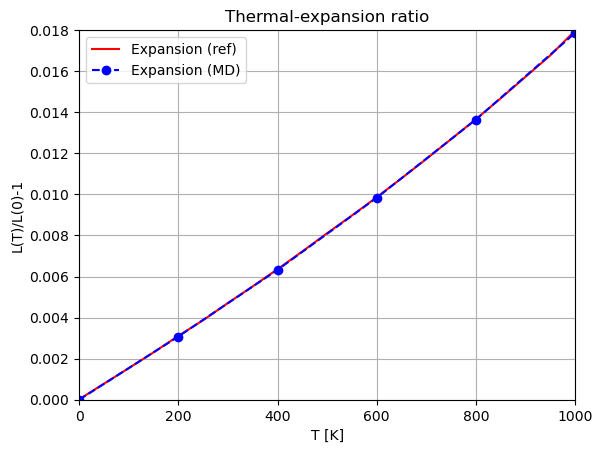

## Temperature-dependent Elastic Constants

In [91]:
def get_stress_tensor_at_finite_temperature(
        structure : Atoms, 
        potential_dataframe : pd.DataFrame, 
        deformation_gradient : np.array, 
        temperature : float,
        run : int, 
        thermo : int, 
        seed : int, 
        thermostat : str
    ):
    
    structure_strained = structure.copy()
    relaxed_cell = np.array(structure_strained.get_cell().tolist())

    strained_cell = deformation_gradient@relaxed_cell
    structure_strained.set_cell(
        strained_cell, 
        scale_atoms=True
        )
    
    if thermostat == 'nose-hoover':
        relaxed_dict = calc_molecular_dynamics_nvt_with_lammpslib(
            structure=structure, 
            potential_dataframe=potential_dataframe,
            Tstart=temperature,
            Tstop=temperature,
            run=run,
            thermo=thermo,
            seed=seed
            )
        strained_dict = calc_molecular_dynamics_nvt_with_lammpslib(
            structure=structure_strained, 
            potential_dataframe=potential_dataframe,
            Tstart=temperature,
            Tstop=temperature,
            run=run,
            thermo=thermo,
            seed=seed
            )
    
    elif thermostat == 'langevin':
        relaxed_dict = calc_molecular_dynamics_langevin_with_lammpslib(
            structure=structure, 
            potential_dataframe=potential_dataframe,
            Tstart=temperature,
            Tstop=temperature,
            run=run,
            thermo=thermo,
            seed=seed
            )
        strained_dict = calc_molecular_dynamics_langevin_with_lammpslib(
            structure=structure_strained, 
            potential_dataframe=potential_dataframe,
            Tstart=temperature,
            Tstop=temperature,
            run=run,
            thermo=thermo,
            seed=seed
            )

    relaxed_dict['pressure_GPa'] = relaxed_dict['pressure'] / 10**4
    strained_dict['pressure_GPa'] = strained_dict['pressure'] / 10**4

    stress_diff = -np.mean(strained_dict['pressure_GPa'][20:] - relaxed_dict['pressure_GPa'][20:], axis=0)

    return stress_diff, relaxed_dict, strained_dict

In [99]:
def calculate_elastic_constants_at_finite_temperature(
        structure : Atoms, 
        potential_name : str, 
        temperature : float = 0, 
        strain : float = 0.005,
        run : int = 10000,
        thermo : int = 100, 
        seed : int = 4928459, 
        thermostat : str = 'langevin'
        ):

    df_pot_selected = get_potential_by_name(
        potential_name=potential_name
    )

    deformation_gradient_dict = get_strain_tensor_cubic(
        structure=structure, 
        strain=strain
        )
    
    tensor_dict = {}
    for constant_str, deformation_gradient in deformation_gradient_dict.items():
        diff, relaxed_dict, strained_dict = get_stress_tensor_at_finite_temperature(
            structure=structure, 
            potential_dataframe=df_pot_selected,
            deformation_gradient=deformation_gradient,
            temperature=temperature,
            run=run,
            thermo=thermo,
            seed=seed,
            thermostat=thermostat
            )
        
        tensor_dict[constant_str] = diff
        tensor_dict[f'relaxed_dict_{constant_str}'] = relaxed_dict
        tensor_dict[f'strained_dict_{constant_str}'] = strained_dict
    
    elastic_constants_list = get_elastic_constants_from_stress_tensor(
        tensor_dict=tensor_dict, 
        strain=strain
        )

    return elastic_constants_list, tensor_dict

#### Nose-hoover vs Langevin

##### Nose-hoover
* x-axis = MD steps
* y-axis = Bar

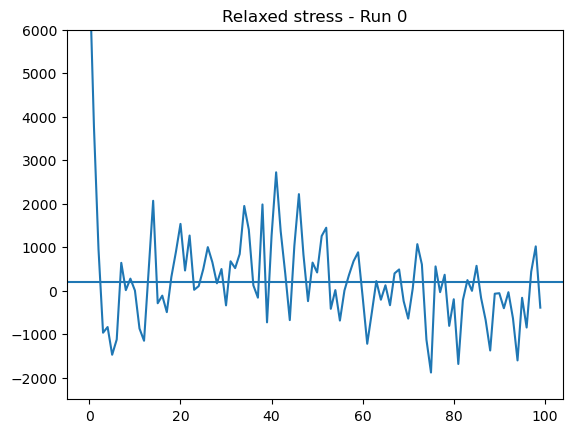

##### Langevin
* x-axis = MD steps
* y-axis = Bar


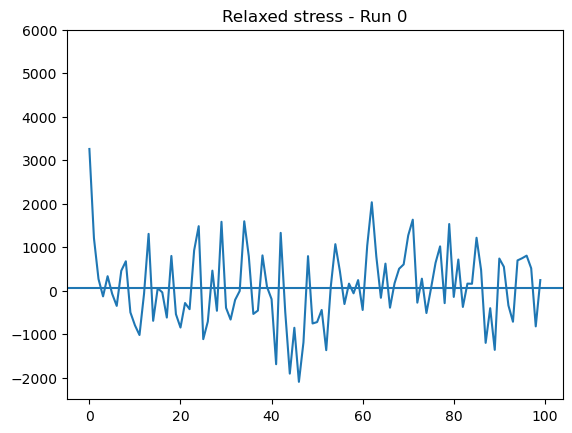

### Different seed

##### Nose-hoover

* x-axis = MD steps
* y-axis = Bar


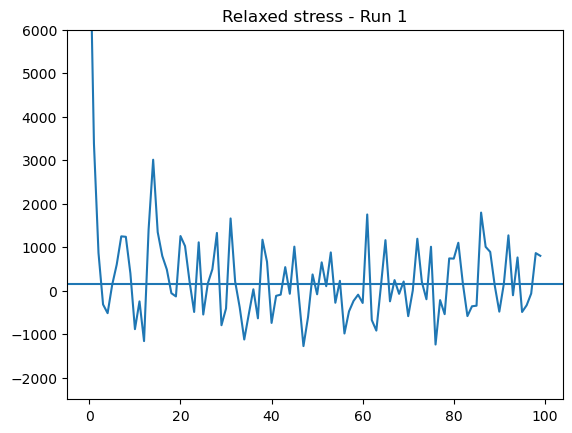

##### Langevin
* x-axis = MD steps
* y-axis = Bar


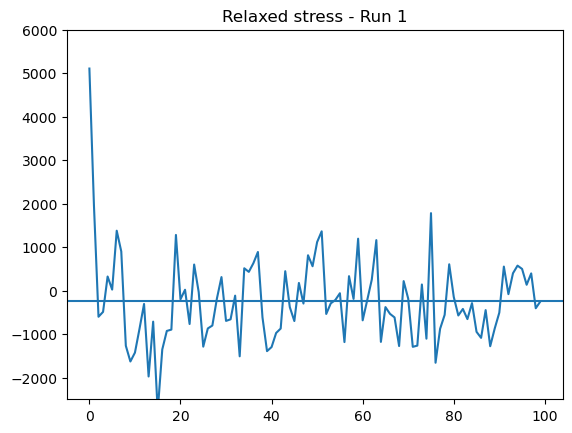

### Comparing with paper

##### Lower strain of 0.0001

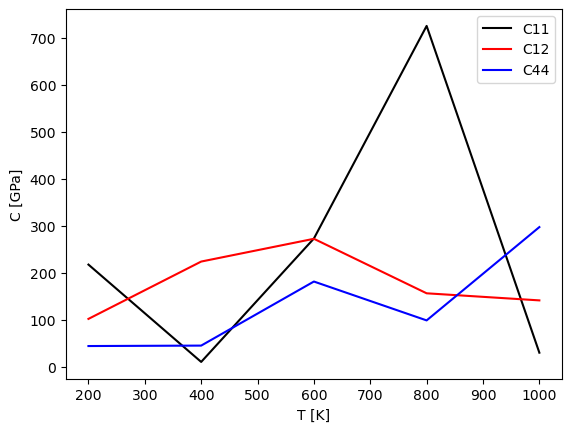

In [92]:
plt.plot(temps, c11s, color='black', label="C11")
plt.plot(temps, c12s, color='red', label="C12")
plt.plot(temps, c44s, color='blue', label="C44")

plt.ylabel('C [GPa]')
plt.xlabel('T [K]')
plt.legend()

Constants from the reference paper:

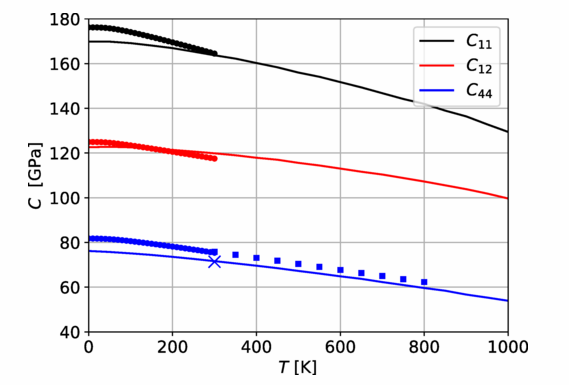

##### Higher strain of 0.005

In [ ]:
input_params_scale = {
    "cell_scale_value" : [5],
    "run" : [10000],
    "temperature" : [100, 200, 300, 400, 500, 600, 700, 800, 900, 1000],
    "strain" : [0.005],
    "seed": [1234],
    "thermostat" : ["langevin"]
}

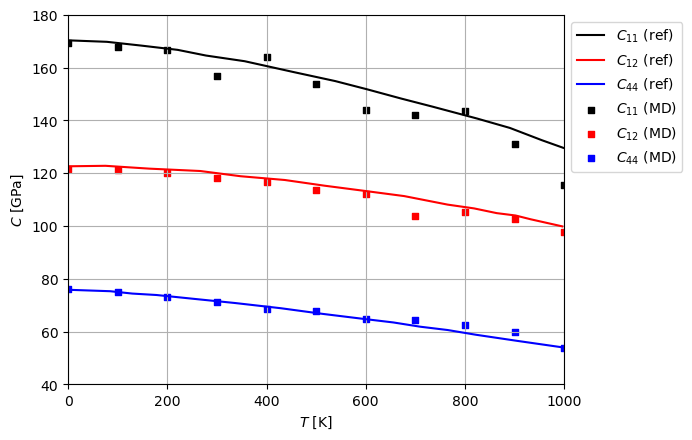

## Convergence Studies

```
input_params_paper = {
    "cell_scale_value": 5,      # 500 atoms
    "run": 200000,              # 2e5 steps  
    "temperature": [0,300,600], # Key points
    "thermostat": "nose-hoover" # Paper's choice
}

```

In [ ]:
input_params_scale = {
    "cell_scale_value" : [3, 5, 7, 9],
    "run" : [5000, 10000, 20000, 30000, 40000, 50000],
    "temperature" : [500],
    "strain" : [0.005],
    "seed": [1357],
    "thermostat" : ["langevin"]
}

### Elastic constant vs MD steps

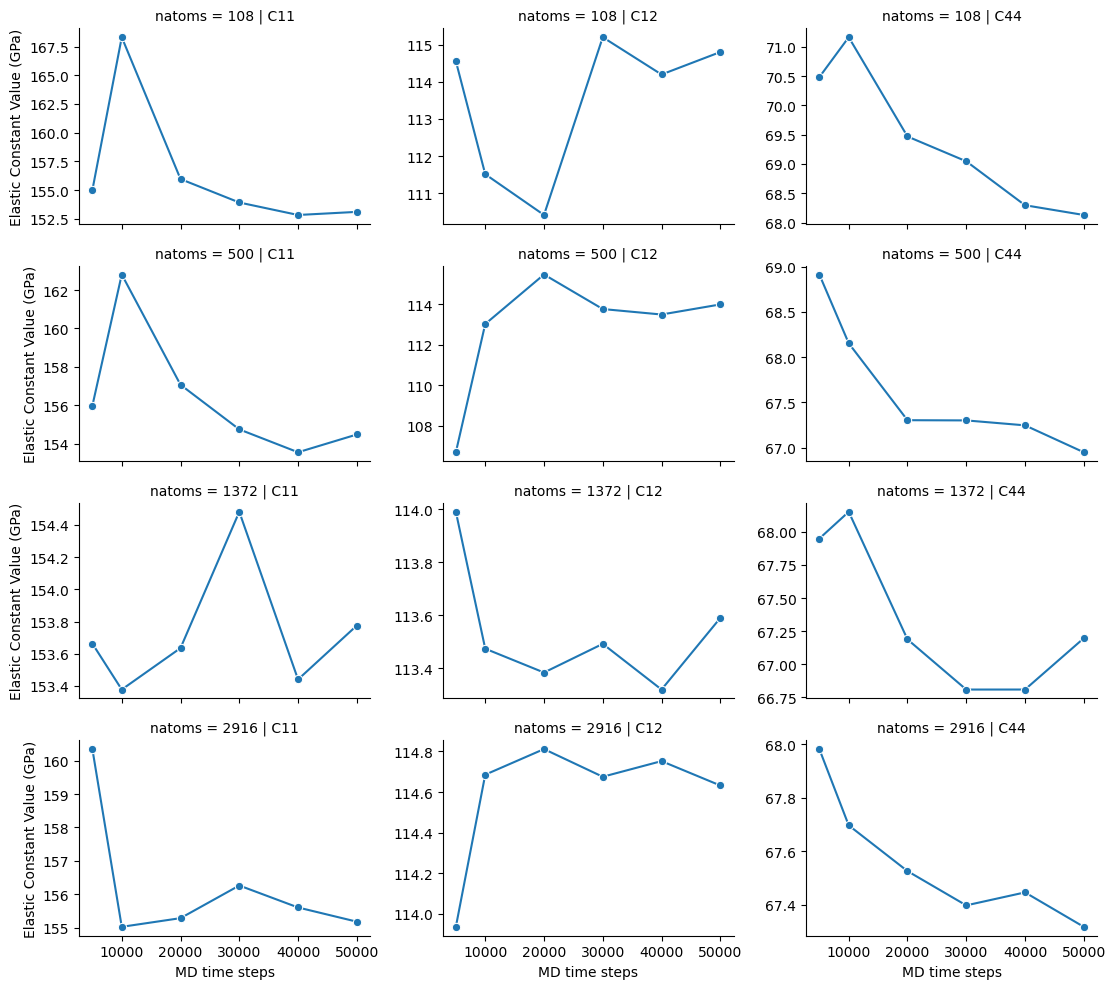

### Elastic constant vs System size

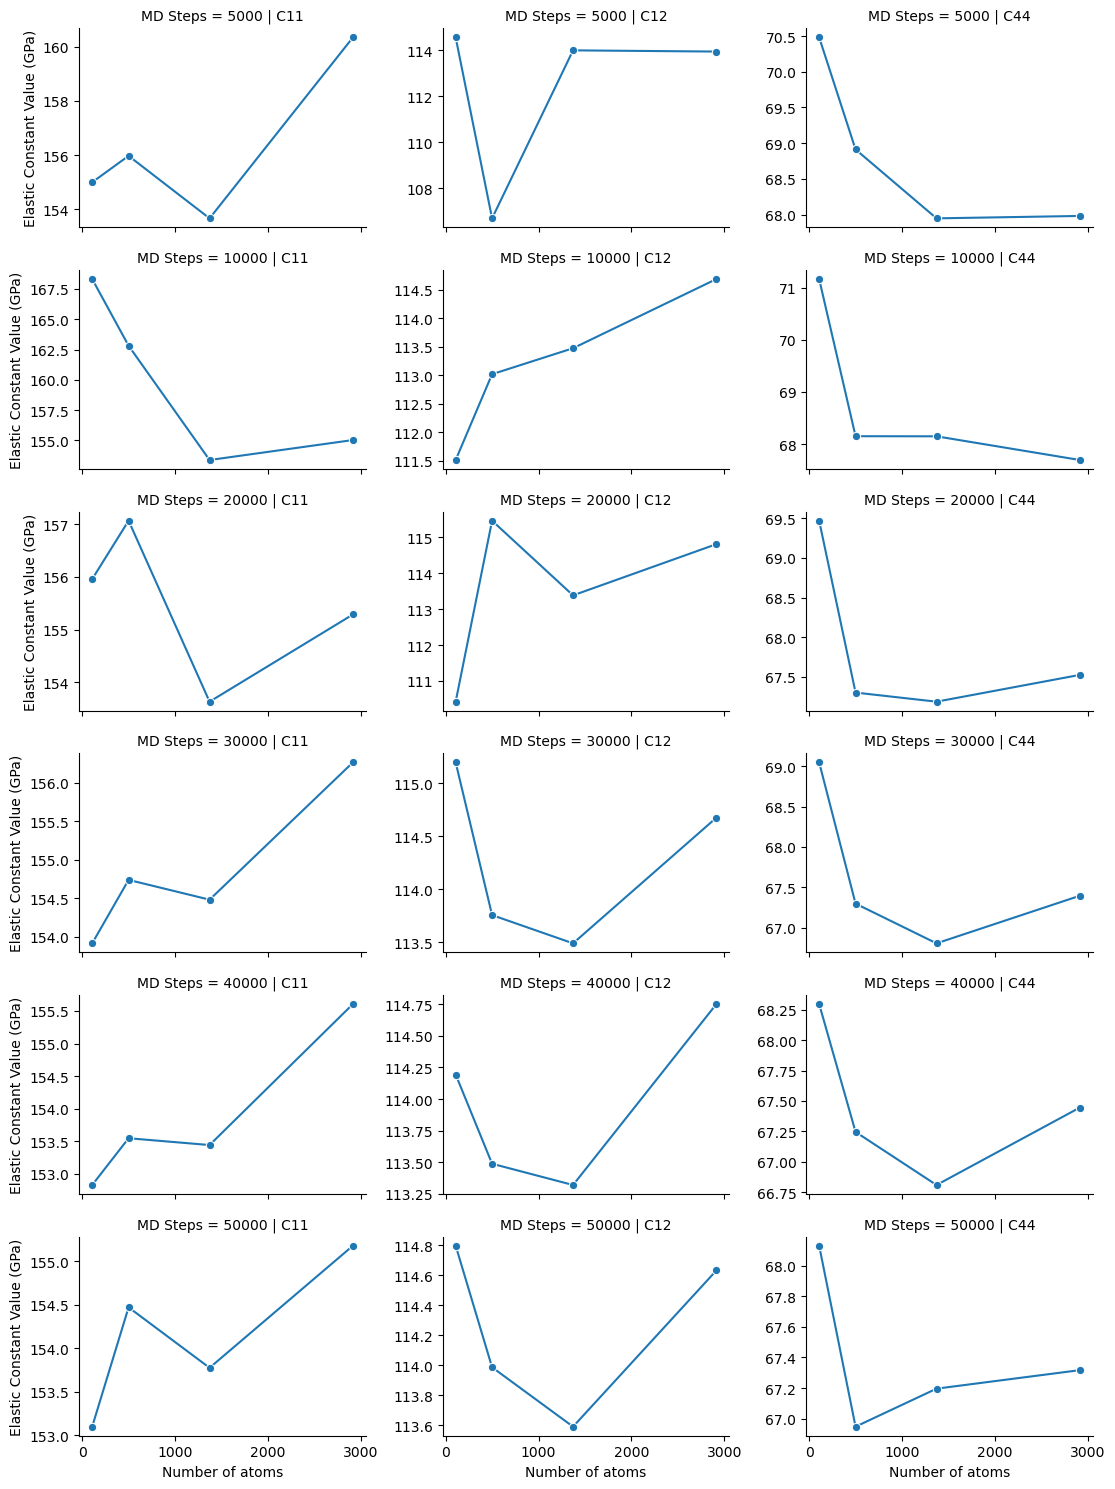